In [1]:
import os
import sys
import random
import numpy as np
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

import tensorflow as tf

from src.networks.DecoderPINN import PINN
from src.optimization.DecoderTrainer import DecoderTrainer
from src.data.decoder_dataloader import load_parametric_fem_data
from src.visualization.historyplots import plot_adam_history
from src.visualization.pdeplots import plot_parametric_pinn_solution
from src.data.collocation import generate_parametric_collocation_points
from src.physics.physics import get_M_dynamic
from src.hyperparameters import hypers_parametric as h

tf.keras.backend.clear_session()
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float32')
number_type = tf.float32

2026-10-03 15:23:35.263401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791033815.271909   77352 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791033815.274667   77352 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791033815.281498   77352 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791033815.281509   77352 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791033815.281510   77352 computation_placer.cc:177] computation placer alr

In [2]:
output_dir = 'models/pipeline_evolution/03_parametric_pinn'
results_dir = 'results/pipeline_evolution/03_parametric_pinn'
data_dir = 'data/parametric/400x400'

train_path = os.path.join(data_dir, 'train.npz')
val_path = os.path.join(data_dir, 'val.npz')
test_path = os.path.join(data_dir, 'test.npz')
scale_save_path = os.path.join(data_dir, 'u_scale.npy')

os.makedirs(output_dir, exist_ok=True)

# Load parametric FEM data
(x_train_pinn, u_train_pinn), (x_val_pinn, u_val_pinn), (x_test_pinn, u_test_pinn), U_SCALE = load_parametric_fem_data(
    train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    scale_save_path=scale_save_path,
    dtype=number_type
)

Loading Parametric FEM data from:
data/parametric/400x400/train.npz
data/parametric/400x400/val.npz
data/parametric/400x400/test.npz
Applied pre-computed noise.
U_SCALE: 0.07277622818946838
Shape x_train: (814980, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)


I0000 00:00:1791033817.601631   77352 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


In [3]:
# Model creation
model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1, 4)))


# Optimizer
initial_learning_rate = 1e-3
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=1000,      
    decay_rate=0.8,        
    staircase=False        
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
optimizer.build(model.trainable_variables)

In [4]:
N_interior = h.N_INTERIOR_ADAM
N_boundary = h.N_BOUNDARY_ADAM
N_activation = h.N_ACTIVATION_ADAM


def point_generator_fn():
    return generate_parametric_collocation_points(
        N_interior=N_interior,
        N_boundary=N_boundary,
        N_activation=N_activation,
        r_a=1.0 / 400,
        dtype=number_type)

In [5]:
# LOSS PARAMETERS
lambdas = {
    'pde': h.LAMBDA_PDE_ADAM,
    'neu': h.LAMBDA_NEU_ADAM,
    'dir': h.LAMBDA_DIR_ADAM,
    'data': h.LAMBDA_DATA_ADAM}

trainer = DecoderTrainer(model=model, output_dir=output_dir, result_dir=results_dir)

trainer.train_adam(optimizer=optimizer,
                   epochs=h.EPOCHS_DECODER_ADAM,
                   x_train=x_train_pinn,
                   u_train=u_train_pinn,
                   x_val=x_val_pinn,
                   u_val=u_val_pinn,
                   physics_fn=get_M_dynamic,
                   lambdas=lambdas,
                   point_generator_fn=point_generator_fn,
                   batch_size=h.BATCH_SIZE_DECODER_ADAM,
                   patience=h.PATIENCE_DECODER_ADAM,
                   number_type=number_type)


Starting Adam optimization...


I0000 00:00:1791033819.234363   77352 service.cc:152] XLA service 0x56f3727648f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791033819.234428   77352 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1791033819.653650   77352 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1791033823.080013   77352 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch    0 | Loss: 1.6164e+00 | PDE: 4.1749e-04 | Dir: 2.7708e-03 | Neu: 3.4118e-05 | Data: 1.3389e-01 | Val: 1.8239e-02
Epoch  500 | Loss: 3.5928e-02 | PDE: 6.6933e-04 | Dir: 4.3242e-06 | Neu: 2.3270e-04 | Data: 3.4824e-03 | Val: 3.4106e-03
Epoch 1000 | Loss: 3.5203e-02 | PDE: 4.9539e-03 | Dir: 2.8625e-06 | Neu: 1.7412e-04 | Data: 2.9961e-03 | Val: 3.0747e-03
Epoch 1500 | Loss: 3.3529e-02 | PDE: 2.3759e-03 | Dir: 1.4995e-06 | Neu: 1.8751e-04 | Data: 3.1001e-03 | Val: 2.9690e-03
Epoch 2000 | Loss: 2.6842e-02 | PDE: 1.9763e-03 | Dir: 1.7139e-06 | Neu: 1.8427e-04 | Data: 2.4693e-03 | Val: 2.9111e-03
Epoch 2500 | Loss: 3.0533e-02 | PDE: 2.2676e-03 | Dir: 7.6523e-07 | Neu: 1.6218e-04 | Data: 2.8188e-03 | Val: 2.8599e-03
Epoch 3000 | Loss: 2.9327e-02 | PDE: 1.7411e-03 | Dir: 1.3745e-06 | Neu: 1.4742e-04 | Data: 2.7447e-03 | Val: 2.8388e-03
Epoch 3500 | Loss: 2.5603e-02 | PDE: 1.4423e-03 | Dir: 5.8263e-07 | Neu: 1.3919e-04 | Data: 2.4101e-03 | Val: 2.8150e-03
Epoch 4000 | Loss: 2.6961e-02 | 

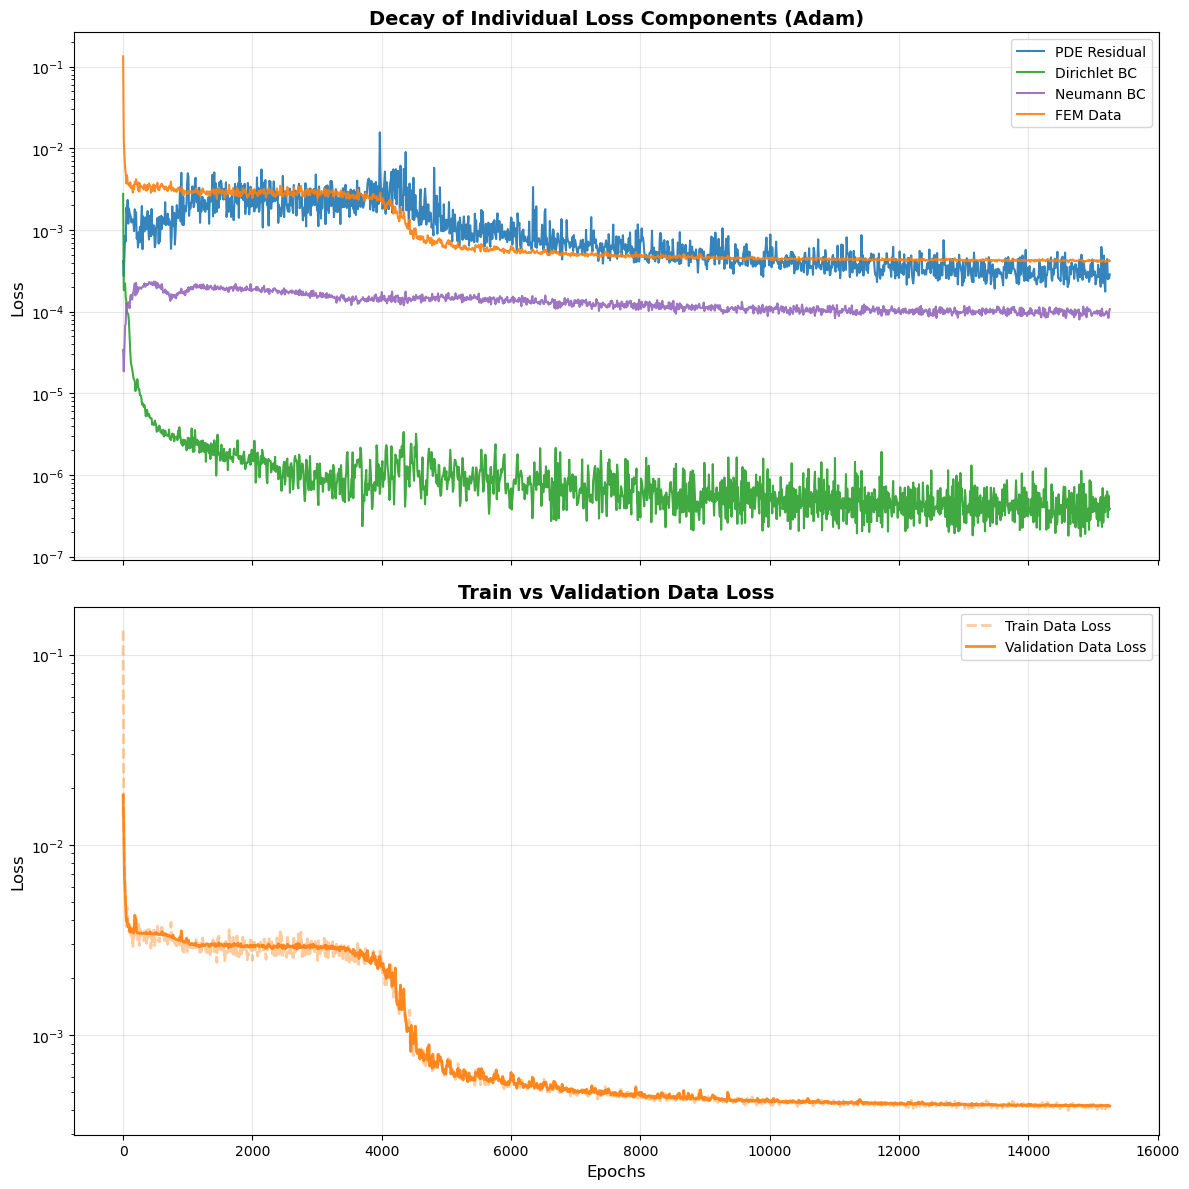

In [6]:
history_adam_path = os.path.join(output_dir, 'decoder_adam.loss.npz')
np.savez(history_adam_path, **trainer.history_adam)
plot_adam_history(trainer.history_adam, save_freq=10)

Generating map for scar at: (0.5, 0.5)


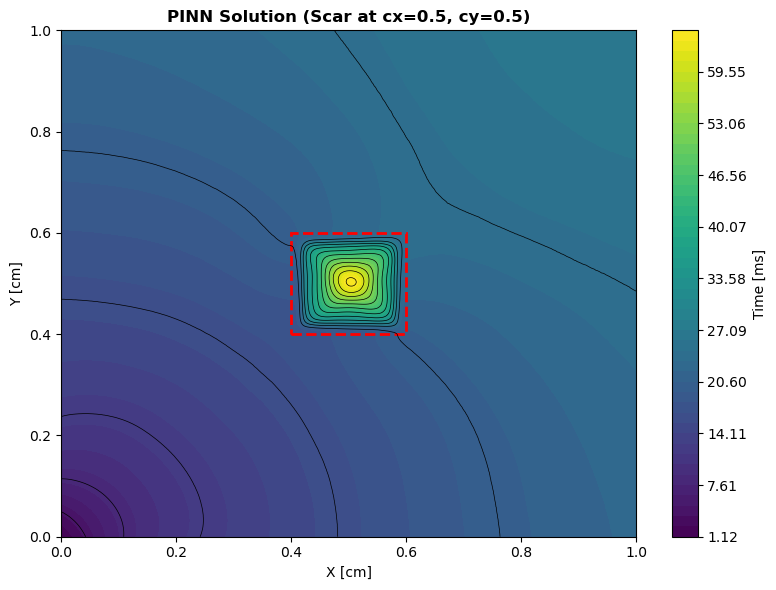

In [7]:
cx_test = 0.5
cy_test = 0.5
print(f"Generating map for scar at: ({cx_test}, {cy_test})")

N_plot = 400 
x_val = np.linspace(0, 1, N_plot)
y_val = np.linspace(0, 1, N_plot)
X, Y = np.meshgrid(x_val, y_val)

X_flat_1D = X.flatten()
Y_flat_1D = Y.flatten()
cx_array = np.full_like(X_flat_1D, cx_test)
cy_array = np.full_like(Y_flat_1D, cy_test)

X_flat_4D = np.column_stack((X_flat_1D, Y_flat_1D, cx_array, cy_array))

u_pred_flat = model(tf.convert_to_tensor(X_flat_4D, dtype=number_type)).numpy() * U_SCALE
U_PINN = u_pred_flat.reshape(N_plot, N_plot) * 1000.0

plot_parametric_pinn_solution(
    X_fem=X, 
    Y_fem=Y, 
    U_pinn2D=U_PINN, 
    cx_test=cx_test, 
    cy_test=cy_test,
)
